# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

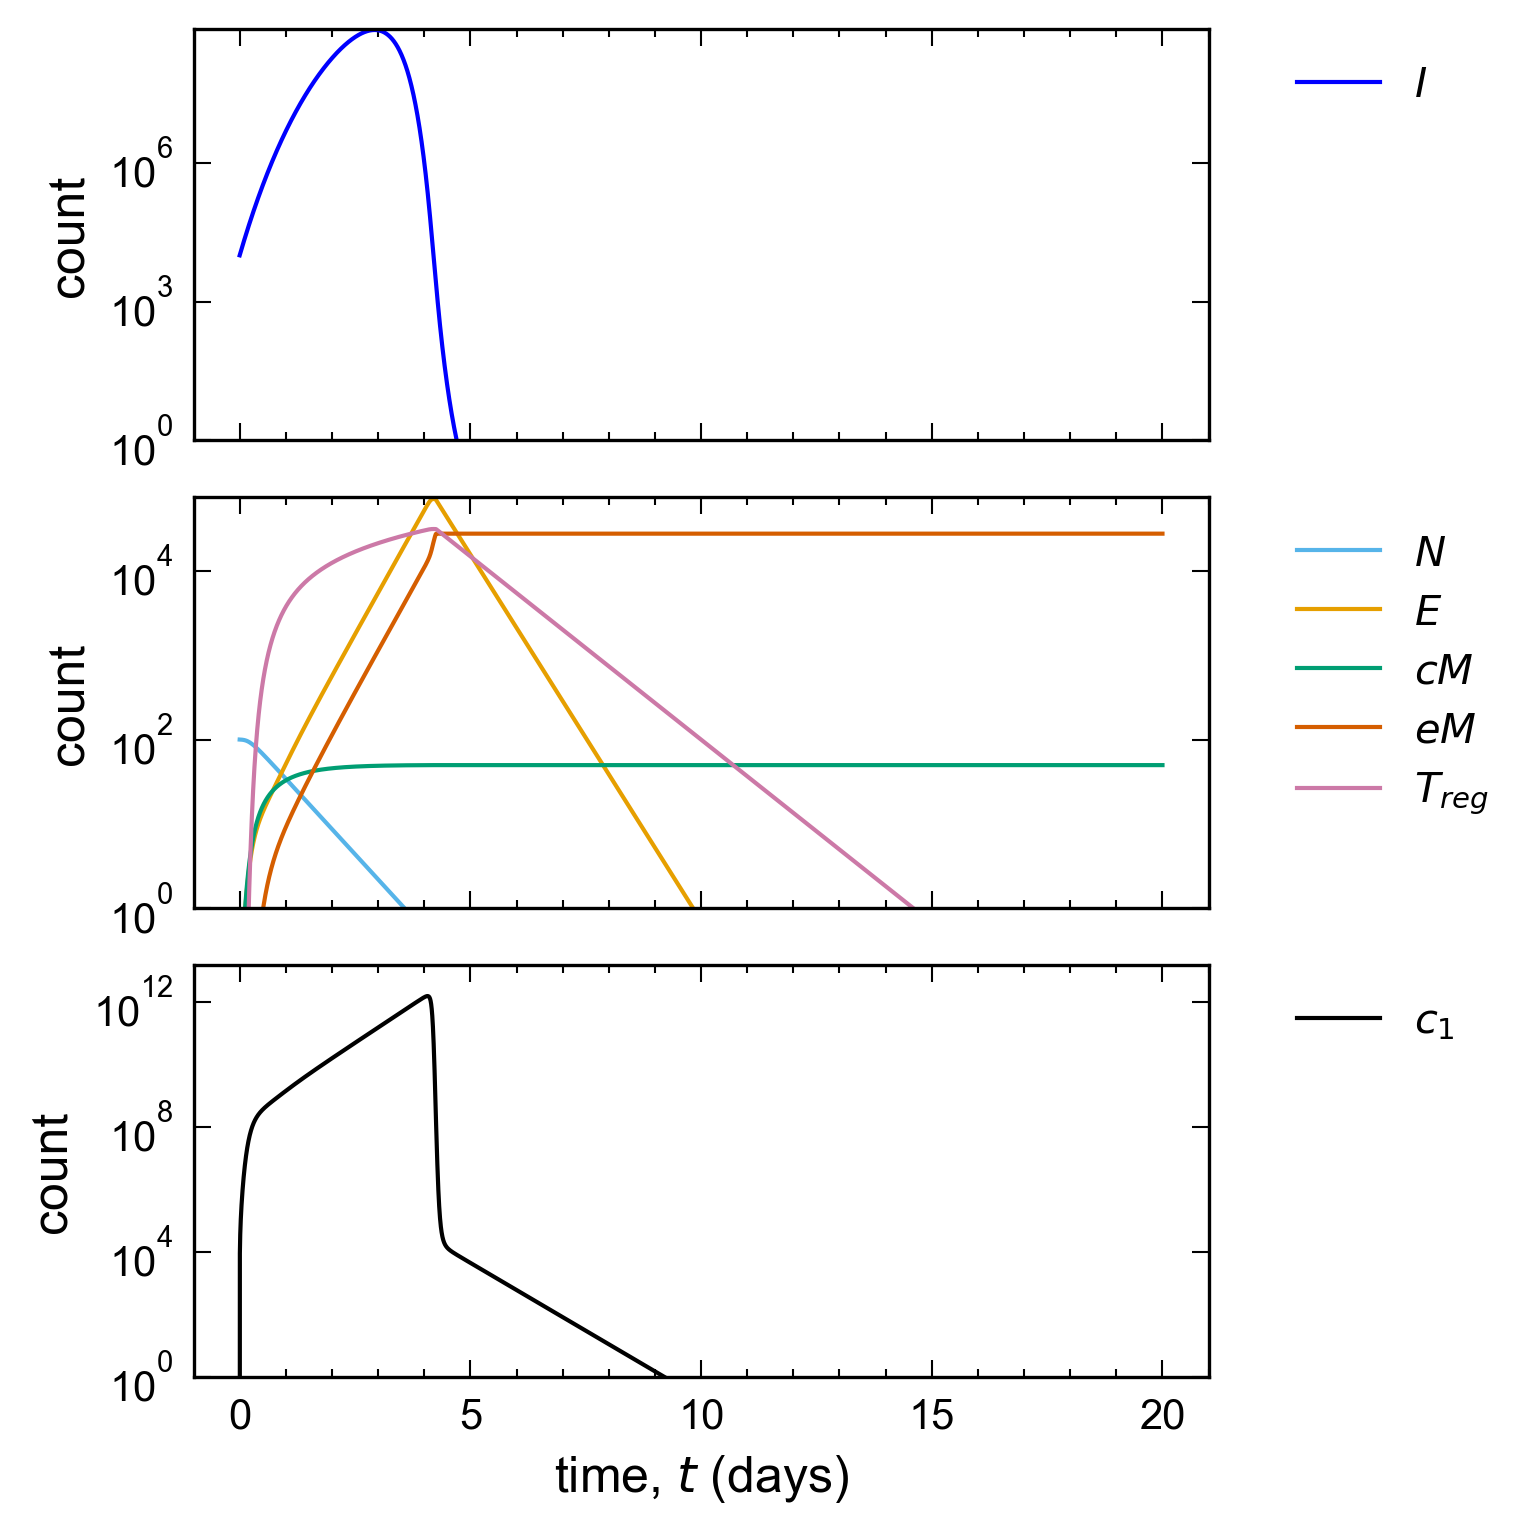

In [2]:
# Plot outputs
I_0 = 10000
b_I = 8
t1 = 10
d_IE = 3.8*10**(-4)
T_I = 2

infection_type = "prim" #"prim"

# rates, I, N, E, cM, eM, T, ts = stoch_sim(I_0, b_I, t1, d_IE, 
#                                     noise_model = "pop", 
#                                     noise_cv = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
#                                     infection = infection_type)

regs, I, N, E, cM, eM, eTr, ts = stoch_sim(I_0 = I_0, b_I = b_I, t1 = t1, d_IE = d_IE, T_I = T_I,
                    infection = infection_type)

fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))
#ax1.plot(ts, I/a2, 'b', label = r'$\frac{a_1}{a_2}$')
ax1.plot(ts, I, 'b', label = r'$I$')
ax1.set(ylabel='count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'$N$')
ax2.plot(ts, E, label = r'$E$')
ax2.plot(ts, cM, label = r'$cM$')
ax2.plot(ts, eM, label = r'$eM$')
ax2.plot(ts, eTr, label = r'$T_{reg}$')
ax2.set(ylabel='count')
ax2.set_ylim(1,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, c1_ss.py_func(t1,I, E, eTr),'k-', label = r'$c_1$')
#ax3.plot(ts, c1_ss(P1.py_func(I, E)[0], E, T)/k_E,'k-', label = r'$\frac{c_1}{k_E}$')
#ax3.plot(ts, c2_ss(I,E),'k-.', label = r'$c_2$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='count')
ax3.semilogy()
ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig(infection_type+'-'+'virus-effector dynamics.pdf', dpi=300, bbox_inches="tight")

In [3]:
rate_cv = [0.5, 0.5, 0.5, 2.0]
rates = [b_N_max, b_E_max, b_cM_max, b_c1]

bN_pop = np.minimum((rates[0] > 0)*np.random.lognormal(mean = np.log(rates[0]/np.sqrt(1 + rate_cv[0]**2) + (rates[0] == 0)), sigma = np.sqrt(np.log(1+ rate_cv[0]**2)), size = N0), 10)
            
bE_pop = np.minimum((rates[1] > 0)*np.random.lognormal(mean = np.log(rates[1]/np.sqrt(1 + rate_cv[1]**2) + (rates[1] == 0)), sigma = np.sqrt(np.log(1+ rate_cv[1]**2)), size = N0), 10)
        
bcM_pop = np.minimum((rates[2] > 0)*np.random.lognormal(mean = np.log(rates[2]/np.sqrt(1 + rate_cv[2]**2) + (rates[2] == 0)), sigma = np.sqrt(np.log(1+ rate_cv[2]**2)), size = N0), 10)
        
bc1_pop = np.random.lognormal(mean = np.log(rates[3]/np.sqrt(1 + rate_cv[3]**2) + (rates[3] == 0)), sigma = np.sqrt(np.log(1+ rate_cv[3]**2)), size = N0)

s = 10
bN = b_N(t1,I[s],E[s],eTr[s], bN_pop)
gNM = g_NM(t1,I[s],E[s],eTr[s], max_val = bN, b_c1_pop = bc1_pop, psi_N_I = psi_N_I, psi_N_c = psi_N_c)
bcM = b_cM(t1,I[s],E[s],eTr[s], max_val = bcM_pop)
gMM = g_MM(t1,I[s],E[s],eTr[s], max_val = bcM, b_c1_pop = bc1_pop, psi_cM_I = psi_cM_I, psi_cM_c = psi_cM_c)
bE = b_E(t1,I[s],E[s],eTr[s], max_val = bE_pop, b_c1_pop = bc1_pop)
gEE = g_EE(t1,I[s],E[s],eTr[s], max_val = bE, b_c1_pop = bc1_pop, psi_E_I = psi_E_I, psi_E_c = psi_E_c)
dE = d_E(t1, I[s],E[s],eTr[s], bE, bc1_pop)

N_pop = np.exp(-bN*s)
dt = duration/steps
dts = np.linspace(0,s, int(s/dt))



# for i, bN_i in enumerate(bN):
#     N_i = np.exp(-bN_i*dts)
#     cM_i = N_i*
    
# print(N)

(1000, 5, 10001)


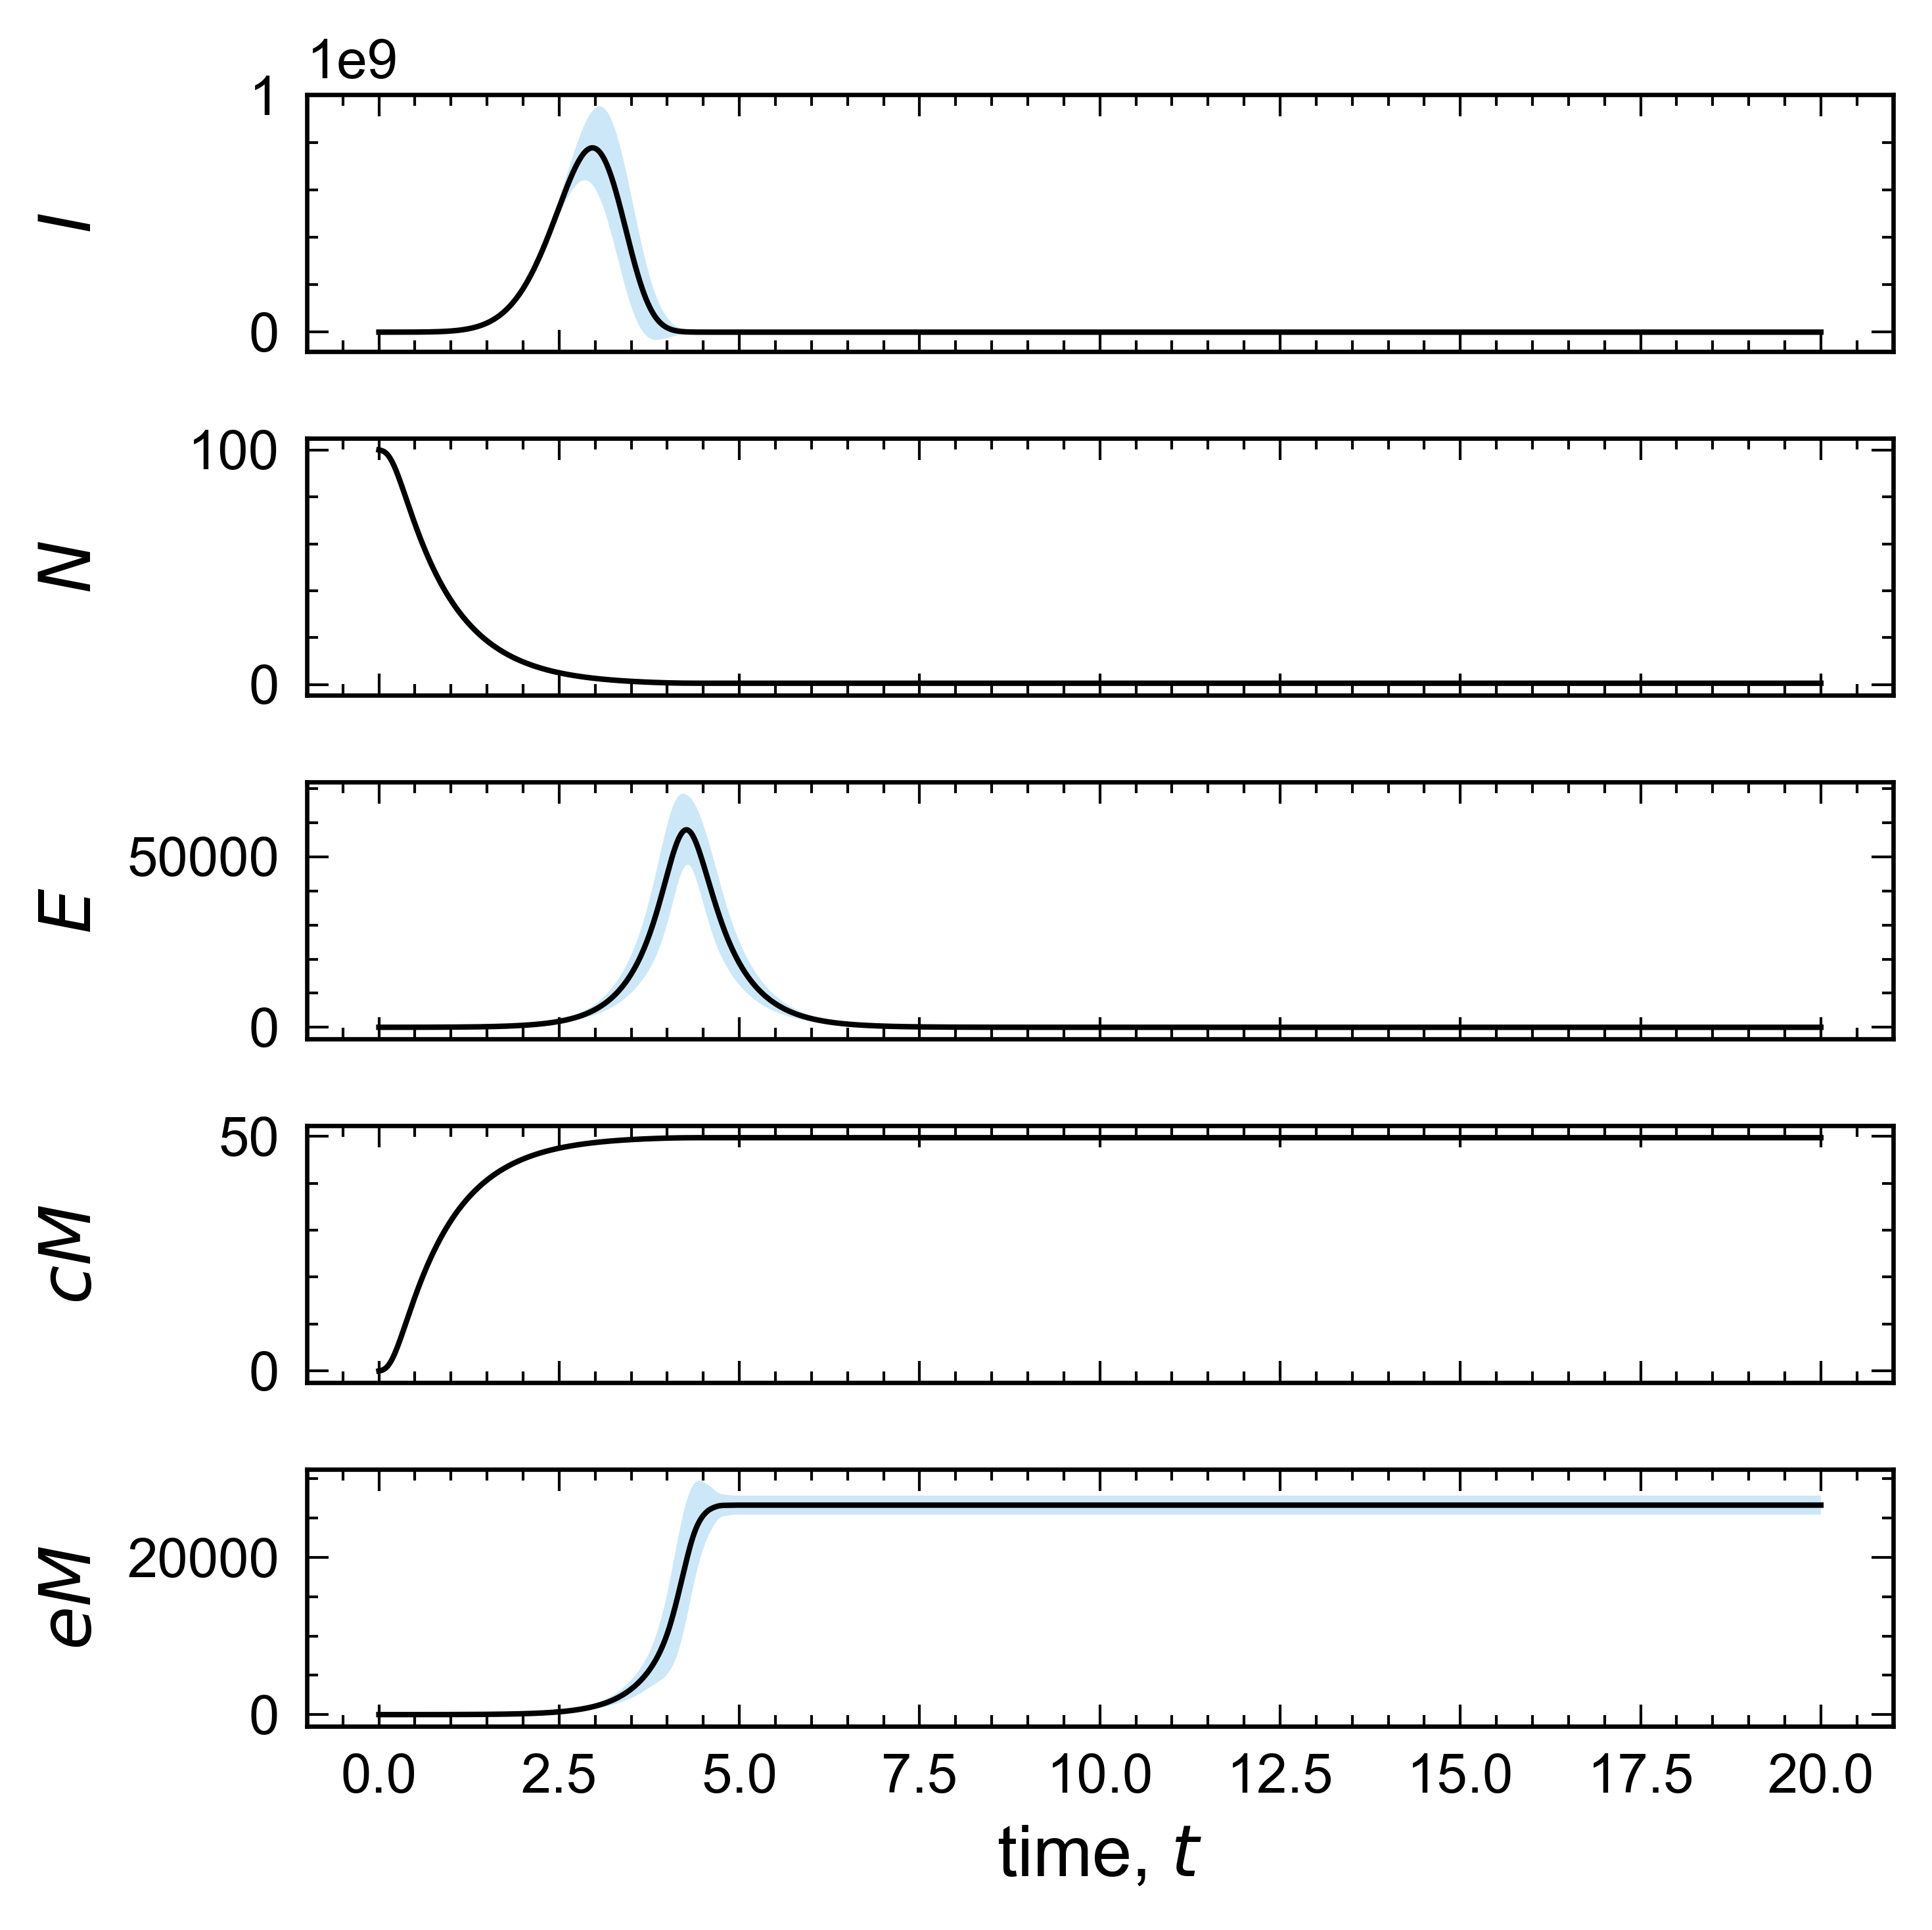

In [4]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5,5), sharex=True, dpi=300)

# This sets how many simulations are performed.
num_realizations = 1000
plot_labels = [r"$I$", r"$N$", r"$E$", r"$cM$", r"$eM$"]

trajectories = np.zeros(shape=(num_realizations, 5, steps+1))
for idx in range(num_realizations):
    _, I, N, E, cM, eM, T, ts = stoch_sim(infection = infection_type)

    trajectories[idx] = I, N, E, cM, eM
print(trajectories.shape)
# Filter out the entries in the numpy array which were full of zeros
# so they aren't plotted.
where_nonzero = np.count_nonzero(trajectories, axis=2).sum(axis=1) != 0
trajectories = trajectories[where_nonzero]

# Compute the mean and standard deviation over all the rows at each column.
# Plot the mean as a solid line and the mean +/- std as fill.
for states, ax in enumerate(axes):
    means = np.mean(trajectories[:,states,:], axis=0)
    stds = np.std(trajectories[:,states,:], axis=0)
    ax.plot(ts, means, 'k-')
    #ax.semilogy()
    ax.fill_between(ts, means - stds, means + stds, alpha=0.3)

# Make legend appear.
# for ax in axes:
#     ax.legend(fontsize=11, frameon=False, loc='upper right') #, bbox_to_anchor=(1.0,0.5))    

# Set xlabel.
for states, ax in enumerate(axes):
    if states == 4:
        ax.set_xlabel('time, $t$', fontsize=13)
    
# Set ylabels.
ylabels = plot_labels
for ax, ylabel in zip(axes, ylabels):
    ax.set_ylabel(ylabel, fontsize=13)

# Align y-axis labels.
fig.align_ylabels(axes)

fig.tight_layout()
plt.show()
fig.savefig(infection_type+'-'+'population-virus-effector dynamics.pdf', dpi=300, bbox_inches="tight")

## (2) Parallelize simulation runs

In [5]:
# Parallelize simulation runs
sim_type = "pop_ode"

def for_parallel(I_params,
                 rate_cv = [0.5, 0.5, 0.5, 2.0],
                 sim_kind = sim_type):
    
    return sum_sim(b_I = I_params[0], t1 = I_params[1], 
                   rate_cv = rate_cv, infection = infection_type, sim_kind = sim_kind)

In [18]:
# Set global simulation parameters
runs = 1_000

In [19]:
# run several simulations varying b_I,t1 indep, logNorm()
cv_b_I, cv_t1 = 0.5, 0.5

Is = np.random.lognormal(mean = np.log(np.array([b_I, t1])/np.sqrt(1 + np.array([cv_b_I, cv_t1])**2)), 
                            sigma = np.sqrt(np.log(1 + np.array([cv_b_I, cv_t1])**2)), size = (runs,2))

run_data = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=max(int(len(Is)/8),1))(delayed(for_parallel)(I_params = I_params)
                                              for I_params in Is), dtype=object)

## (3) Plot distribution of response statistics from simulations varying $b_{I}$ and $t_1$

In [20]:
run_rates = np.zeros((runs, len(run_data[:,0][0]) ))
run_data_Is = np.zeros((runs, len(run_data[:,1][0]) ))

for i in np.arange(0,runs):
    run_rates[i,:] = run_data[:,0][i]
    run_data_Is[i,:] = run_data[:,1][i]

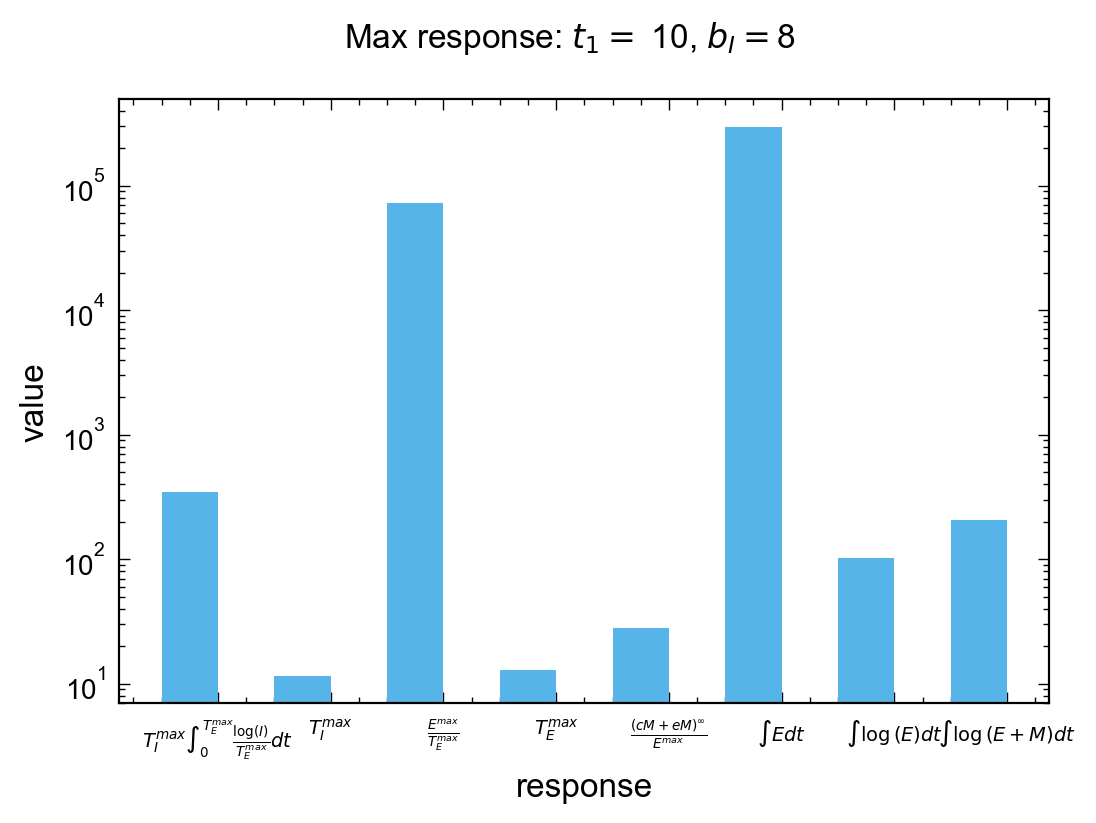

In [21]:
# Compute max values in the data
r = 2*np.arange(len(stat_names)-10)
width = 1
plt.bar(r, np.amax(run_data_Is[:,10:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + width/2,stat_names[10:], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Max response: $t_1=$ '+str(t1) +r', $b_I=$'+str(b_I))
plt.savefig(sim_type+'-'+infection_type+'-'+'response-max'+'.png', dpi=150)

[5.00000000e-01 5.00000000e-01 5.00000000e-01 5.00000000e-01
 9.00000000e-01 9.00000000e-01 1.00000000e+04 3.23251558e+00
 1.58778510e+01 3.80000000e-04 2.14675021e+01 1.90800000e+00
 1.35363884e+04 2.94600000e+00 4.14508207e-01 4.01542327e+04
 7.64385895e+01 1.86897427e+02]
[5.00000000e-01 5.00000000e-01 5.00000000e-01 5.00000000e-01
 9.00000000e-01 9.00000000e-01 1.00000000e+04 2.96143225e+01
 1.15308412e+01 3.80000000e-04 1.17043740e+02 3.03200000e+00
 7.24467255e+04 4.30800000e+00 1.90016247e-01 2.98215958e+05
 9.57036487e+01 2.07656109e+02]
[1.49258260e+00 3.01587605e+00 9.54444419e-01 8.90775843e+07]


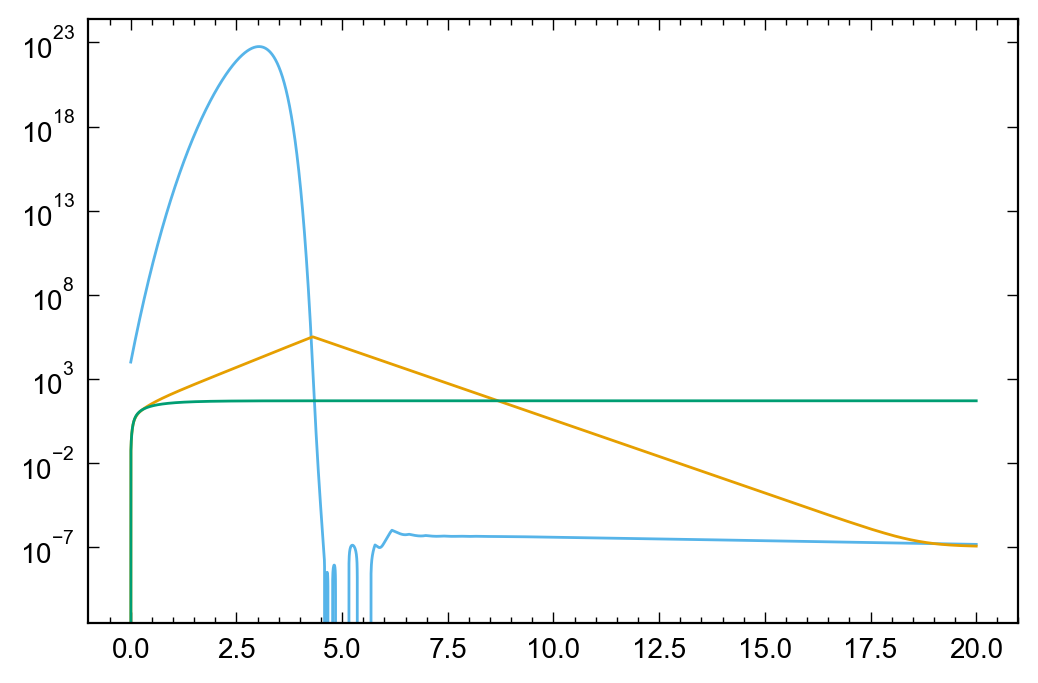

In [22]:
# # Troubleshooting outliers
print(run_data_Is[np.argmin(run_data_Is[:, 11]),:])
print(run_data_Is[np.argmax(run_data_Is[:, 15]),:])
immune_param= run_rates[np.argmax(run_data_Is[:, 15]), :]
virus_param = (run_data_Is[np.argmax(run_data_Is[:, 15]), :])[6:10]

rates, I, N, E, cM, eM, T, ts = stoch_sim(virus_param[0], virus_param[1], virus_param[2], virus_param[3],
                                          rates = immune_param,
                                          noise_model = "pop", 
                                          rate_cv = [0.0, 0.0, 0.0, 0.0],
                                          infection = infection_type)

plt.plot(ts,np.array([I, E, cM]).T)
plt.semilogy()
# plt.plot(ts,np.array([p_A(t1,I)]).T)

print(immune_param)

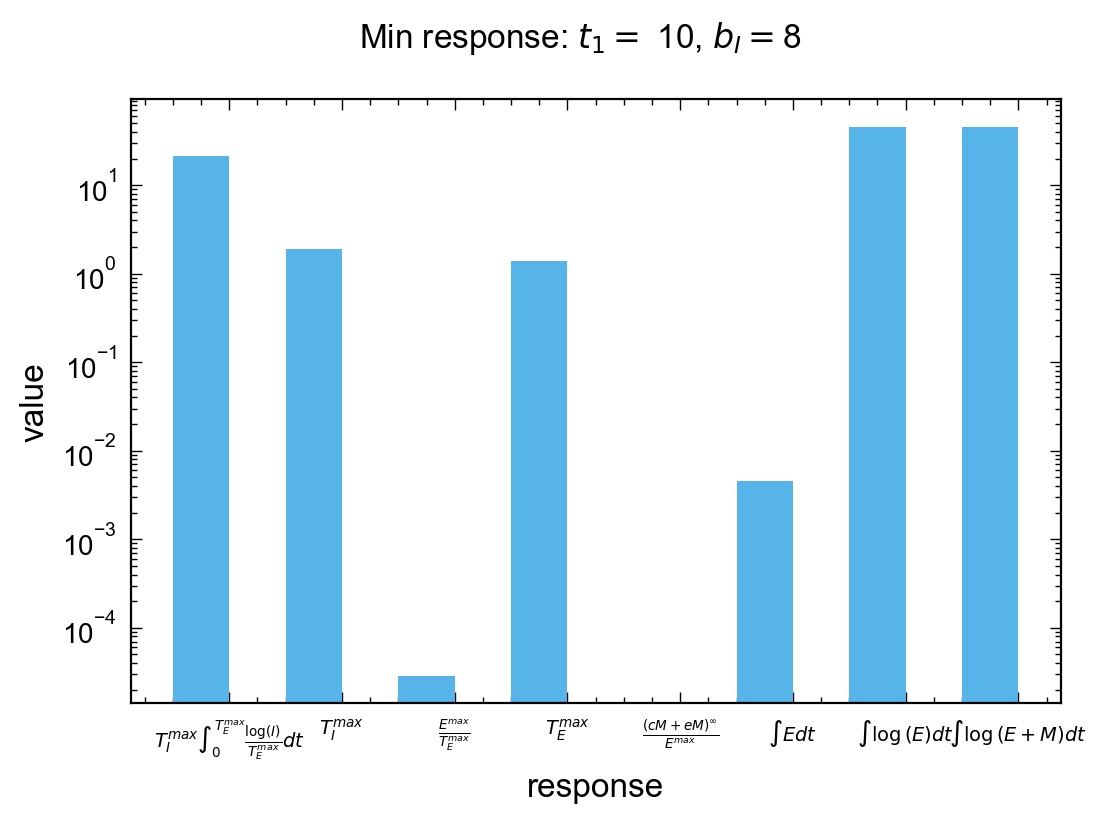

In [23]:
# Compute minimum values in the data
r = 2*np.arange(len(stat_names)-10)
width = 1
plt.bar(r, np.amin(run_data_Is[:,10:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + width/2,stat_names[10:], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Min response: $t_1=$ '+str(t1) +r', $b_I=$'+str(b_I))
plt.savefig(sim_type+'-'+infection_type+'-'+'response-min'+'.png', dpi=150)

## (4) Compute mutual information between variables

In [24]:
# compute mutual information
MI_b_I = np.zeros(run_data_Is.shape[1])
for i in np.hstack(([7],np.arange(10,len(stat_names)))):
    MI_b_I[i] = calc_MI(run_data_Is[:,7],run_data_Is[:,i])

MI_t1 = np.zeros(run_data_Is.shape[1])
for i in np.hstack(([8],np.arange(10,len(stat_names)))):
    MI_t1[i] = calc_MI(run_data_Is[:,8],run_data_Is[:,i])

Text(0.5, 0.98, 'Entropy in generated data')

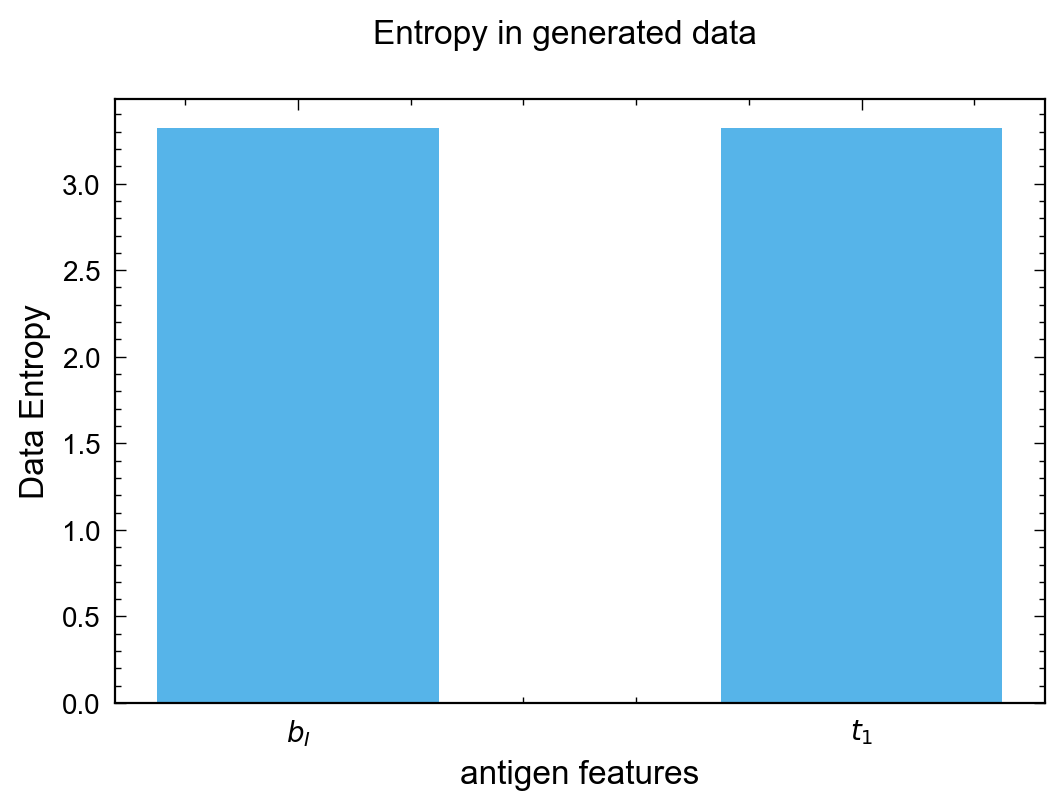

In [25]:
# Plot Data Entropy
plt.figure(1)

r = np.arange(2)
width = 0.5
plt.bar(r, np.array([MI_b_I[7],MI_t1[8]]), width = width)

plt.xlabel("antigen features")
plt.ylabel("Data Entropy")

plt.xticks(r,stat_names[7:9])
plt.suptitle(r'Entropy in generated data')
#plt.savefig(infection_type+'-'+'response-mutual-info-gauss-t1-'+str(t1)+'.png', dpi=150, bbox_inches="tight")

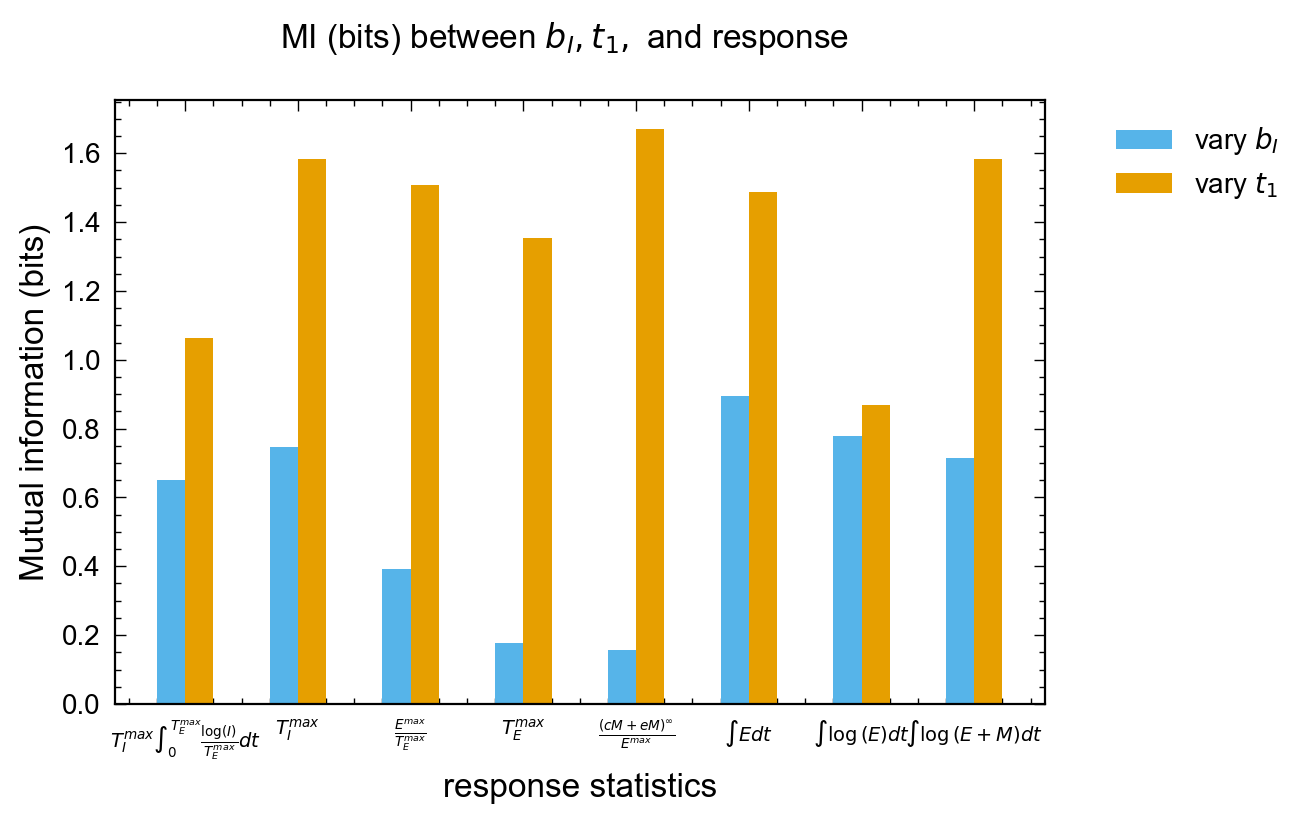

In [26]:
# Plot mutual information
plt.figure(1)

r = 2*np.arange(len(MI_b_I[10:]))
width = 0.5
plt.bar(r, MI_b_I[10:], width = width, label = r'vary $b_{I}$')
plt.bar(r + width, MI_t1[10:], width = width, label = r'vary $t_1$')


plt.xlabel("response statistics")
plt.ylabel("Mutual information (bits)")

plt.xticks(r + width/2,stat_names[10:],fontsize=7)
#plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle(r'MI (bits) between $b_{I}, t_1,$ and response')
plt.savefig(sim_type+'-'+infection_type+'-'+'response-mutual-info-gauss-t1-'+str(t1)+'.png', dpi=150, bbox_inches="tight")

## (5) Plot trajectories from simulations

In [15]:
# Plot trajectories for b_I

# fig_b_I.suptitle(r'Immune response varying $b_{a_1}$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_b_I.savefig('plot-response-varying-b_I-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[10:]
xlabels = [stat_names[7]]*len(ylabels)

fig_b_I = joint_plot_grid([run_data_Is[:,7]]* len(ylabels), run_data_Is[:,10:].T.tolist(), granularity=50,
                use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_b_I.savefig(sim_type+'-'+infection_type+'-'+'plot-response-varying-b_I.png', dpi=150,bbox_inches="tight")


/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


In [16]:
# Plot trajectories for t1
# fig_t1.suptitle(r'Immune response while varying $t_1$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_t1.savefig('plot-response-varying-t1-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[10:]
xlabels = [stat_names[8]]*len(ylabels)

fig_t1 = joint_plot_grid([run_data_Is[:,8]]*len(ylabels), run_data_Is[:,10:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_t1.savefig(sim_type+'-'+infection_type+'-'+'plot-response-varying-t1.png', dpi=150)

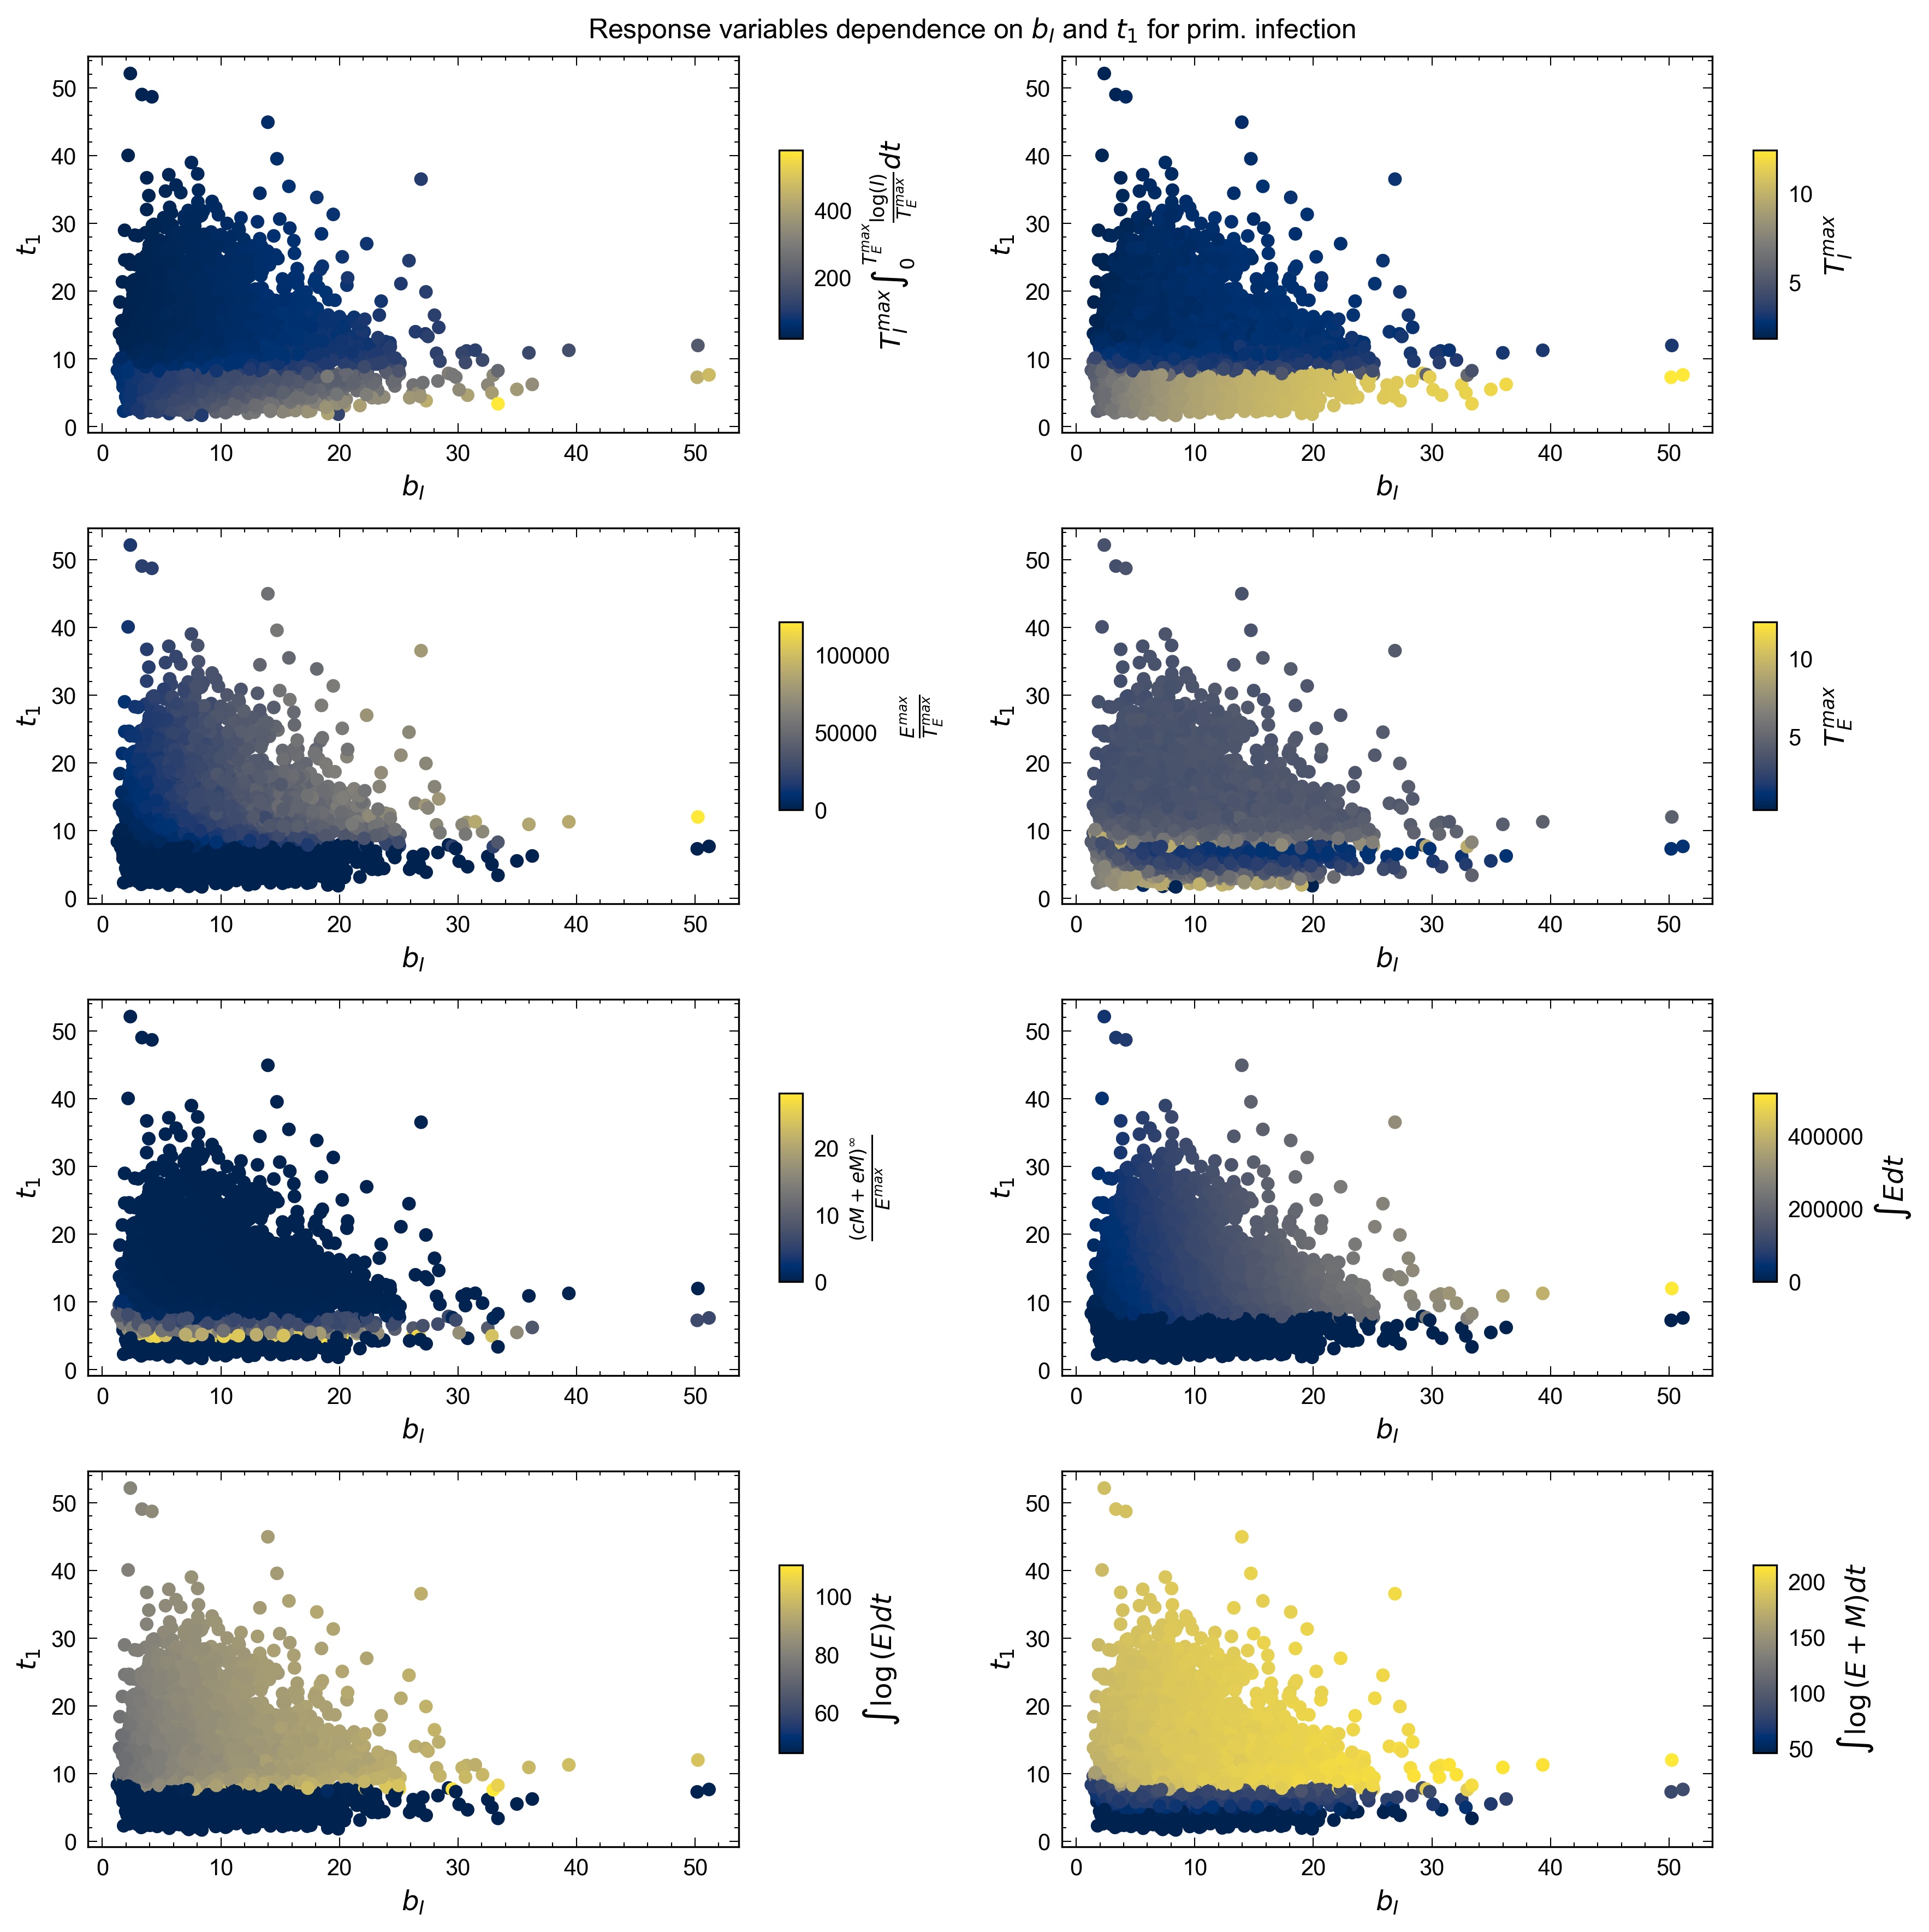

In [17]:
# plot surface plots
fig = plt.figure(figsize=(12,12),dpi = 150)

i = 1

for val in stat_names[i+9:]:

    ax = fig.add_subplot(4, 2, i) #, projection='3d')
    
    # set the limits of the plot to the limits of the data
    img = ax.scatter(run_data_Is[:10000,7], run_data_Is[:10000,8], c = run_data_Is[:10000,i+9], cmap=plt.cm.cividis)
    ax.set(xlabel=r'$b_I$', ylabel=r'$t_1$')
    fig.colorbar(img,  shrink=0.5, aspect=8, label =val)

    i += 1
    
fig.suptitle(r'Response variables dependence on $b_I$ and $t_1$'+' for '+infection_type+". infection")
fig.savefig(sim_type+'-'+infection_type+'-'+'response-distribution.pdf', dpi=150, bbox_inches="tight")
plt.tight_layout()

plt.show()